In [1]:
!pip install ultralytics matplotlib pandas opencv-python

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive






```



import json
import os
import cv2
import shutil

# --- 1. Colab Configuration ---
base_path = '/content/drive/MyDrive/car_damage_project'

# The exact classes found in your JSON
class_mapping = {
    'mat_bo_phan': 0, # Missing part
    'rach': 1,        # Tear/Crack
    'mop_lom': 2,     # Dent
    'tray_son': 3     # Scratch
}

# --- Settings for Training Run (Change these 3 lines for validation) ---
json_file = os.path.join(base_path, '0Train_via_annos.json')
source_image_folder = os.path.join(base_path, 'image','image')
split_name = 'train'
# -----------------------------------------------------------------------

output_base_dir = os.path.join(base_path, 'yolo_dataset')
output_images_dir = os.path.join(output_base_dir, 'images', split_name)
output_labels_dir = os.path.join(output_base_dir, 'labels', split_name)
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

# --- 2. Process the JSON ---
with open(json_file, 'r') as f:
    try:
        images_data = json.load(f)
    except Exception as e:
        print(f"Error loading JSON: {e}")
        exit()

print(f"Converting images for {split_name}...")

for img_id, img_metadata in images_data.items():
    filename = img_metadata.get('name')
    if not filename:
        continue
        
    img_path = os.path.join(source_image_folder, filename)
    
    if not os.path.exists(img_path):
        continue # Skip quietly if image is missing from folder

    img = cv2.imread(img_path)
    if img is None:
        continue
    img_height, img_width, _ = img.shape

    label_filename = os.path.splitext(filename)[0] + '.txt'
    label_path = os.path.join(output_labels_dir, label_filename)

    with open(label_path, 'w') as label_file:
        regions = img_metadata.get('regions', [])
        
        for region in regions:
            # Extract directly from the region dictionary
            all_x = region.get('all_x', [])
            all_y = region.get('all_y', [])
            class_name = region.get('class')

            # Skip if data is malformed or class is missing
            if not all_x or not all_y or class_name not in class_mapping:
                continue

            # Calculate bounding box
            xmin, xmax = min(all_x), max(all_x)
            ymin, ymax = min(all_y), max(all_y)
            w = xmax - xmin
            h = ymax - ymin

            # Normalize for YOLO
            x_center = (xmin + w / 2.0) / img_width
            y_center = (ymin + h / 2.0) / img_height
            norm_w = w / img_width
            norm_h = h / img_height
            
            class_id = class_mapping[class_name]

            label_file.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

    shutil.copy(img_path, os.path.join(output_images_dir, filename))

print(f"Data pipeline complete for {split_name}!")



```



import json
import os
import cv2
import shutil

#--- 1. Colab Configuration ---
base_path = '/content/drive/MyDrive/car_damage_project'

 The exact classes found in your JSON
class_mapping = {
    'mat_bo_phan': 0, # Missing part
    'rach': 1,        # Tear/Crack
    'mop_lom': 2,     # Dent
    'tray_son': 3     # Scratch
}




 #--- Settings for Training Run (Change these 3 lines for validation) ---
json_file = os.path.join(base_path, '0Val_via_annos.json')
source_image_folder = os.path.join(base_path, 'validation','validation')
split_name = 'val'
#-----------------------------------------------------------------------

output_base_dir = os.path.join(base_path, 'yolo_dataset')
output_images_dir = os.path.join(output_base_dir, 'images', split_name)
output_labels_dir = os.path.join(output_base_dir, 'labels', split_name)
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

#--- 2. Process the JSON ---
with open(json_file, 'r') as f:
    try:
        images_data = json.load(f)
    except Exception as e:
        print(f"Error loading JSON: {e}")
        exit()

print(f"Converting images for {split_name}...")


for img_id, img_metadata in images_data.items():
    filename = img_metadata.get('name')
    if not filename:
        continue
        
    img_path = os.path.join(source_image_folder, filename)
    
    if not os.path.exists(img_path):
        continue # Skip quietly if image is missing from folder

    img = cv2.imread(img_path)
    if img is None:
        continue
    img_height, img_width, _ = img.shape

    label_filename = os.path.splitext(filename)[0] + '.txt'
    label_path = os.path.join(output_labels_dir, label_filename)

    with open(label_path, 'w') as label_file:
        regions = img_metadata.get('regions', [])
        
        for region in regions:
            # Extract directly from the region dictionary
            all_x = region.get('all_x', [])
            all_y = region.get('all_y', [])
            class_name = region.get('class')

            # Skip if data is malformed or class is missing
            if not all_x or not all_y or class_name not in class_mapping:
                continue

            # Calculate bounding box
            xmin, xmax = min(all_x), max(all_x)
            ymin, ymax = min(all_y), max(all_y)
            w = xmax - xmin
            h = ymax - ymin

            # Normalize for YOLO
            x_center = (xmin + w / 2.0) / img_width
            y_center = (ymin + h / 2.0) / img_height
            norm_w = w / img_width
            norm_h = h / img_height
            
            class_id = class_mapping[class_name]

            label_file.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

    shutil.copy(img_path, os.path.join(output_images_dir, filename))

print(f"Data pipeline complete for {split_name}!")


'''

In [3]:
import yaml
import os

dataset_path = '/content/drive/MyDrive/car_damage_project/yolo_dataset'

data_yaml = {
    'train': os.path.join(dataset_path, 'images', 'train'),
    'val': os.path.join(dataset_path, 'images', 'val'),
    'nc': 4,
    'names': ['mat_bo_phan', 'rach', 'mop_lom', 'tray_son']
}

yaml_file_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_file_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print("data.yaml successfully created!")

data.yaml successfully created!


In [2]:
from ultralytics import YOLO

# Load the base model
model = YOLO('yolo11n.pt')

# Start training
print("Starting YOLOv11 training...")
results = model.train(
    data='/content/drive/MyDrive/car_damage_project/yolo_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16, # Change to 8 if Colab runs out of memory
    project='/content/drive/MyDrive/car_damage_project',
    name='damage_model_v1'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting YOLOv11 training...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/car_damage_project/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.

Testing on: 06012020_103807image296107.jpg

image 1/1 /content/drive/MyDrive/car_damage_project/yolo_dataset/images/val/06012020_103807image296107.jpg: 480x640 2 rachs, 9.4ms
Speed: 2.8ms preprocess, 9.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


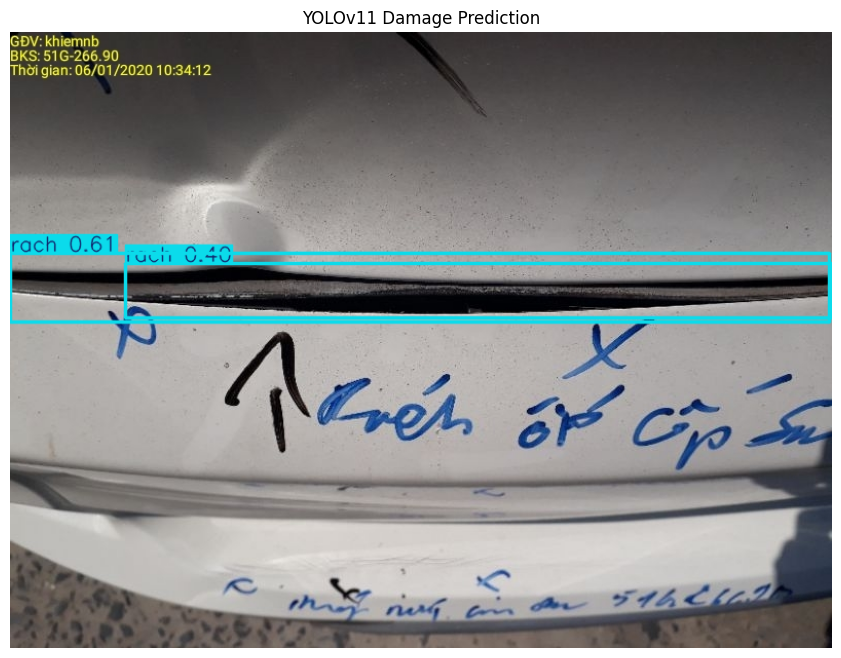

In [9]:
import glob
import random
import cv2
import matplotlib.pyplot as plt

# 1. Get a list of all your validation images
val_images = glob.glob('/content/drive/MyDrive/car_damage_project/yolo_dataset/images/val/*.jpg')

# 2. Pick one at random
test_image = random.choice(val_images)
print(f"Testing on: {test_image.split('/')[-1]}")

# 3. Run the prediction (conf=0.4 means ignore guesses under 40% confidence)
results = model.predict(source=test_image, conf=0.4)

# 4. Plot the image with the predicted boxes
res_plotted = results[0].plot()

# 5. Display it in Colab
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLOv11 Damage Prediction")
plt.show()

In [10]:
from ultralytics import YOLO

# 1. Load YOUR custom-trained model
# (Double-check that 'damage_model_v1' matches the folder name from your training step)
model_path = '/content/drive/MyDrive/car_damage_project/damage_model_v1/weights/best.pt'
model = YOLO(model_path)

# 2. Run the validation sequence
print("Running validation sequence...")
metrics = model.val(
    data='/content/drive/MyDrive/car_damage_project/yolo_dataset/data.yaml',
    split='val',   # Tells it to only grade itself on the validation folder
    conf=0.25      # Only counts predictions where it is at least 25% sure
)

# 3. Print the final report card
print("\n--- MODEL REPORT CARD ---")
print(f"mAP50 (Accuracy at 50% overlap): {metrics.box.map50 * 100:.2f}%")
print(f"mAP50-95 (Strict Accuracy):      {metrics.box.map * 100:.2f}%")

Running validation sequence...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 54.2±19.5 MB/s, size: 129.7 KB)
val: Scanning /content/drive/MyDrive/car_damage_project/yolo_dataset/labels/val.cache... 1214 images, 181 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1214/1214 268.0Mit/s 0.0s
val: /content/drive/MyDrive/car_damage_project/yolo_dataset/images/val/03012020_164414image176239.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0403]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 2.9it/s 26.5s
                   all       1213       2432      0.395      0.246      0.176      0.103
           mat_bo_phan        172        189      0.545      0.444      0.379      0.256
                  rach        310        442      